In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from src.MBT import mean_below_threshold as mbt

In [2]:
wind = xr.open_dataset("data/processed/daily-state-cf/wind_daily-state-cf.nc")
solar = xr.open_dataset("data/processed/daily-state-cf/solar_daily-state-cf.nc")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
wind_winter = wind.sel(time=wind.time.dt.month.isin([6, 7, 8]))
solar_winter = solar.sel(time=solar.time.dt.month.isin([6, 7, 8]))

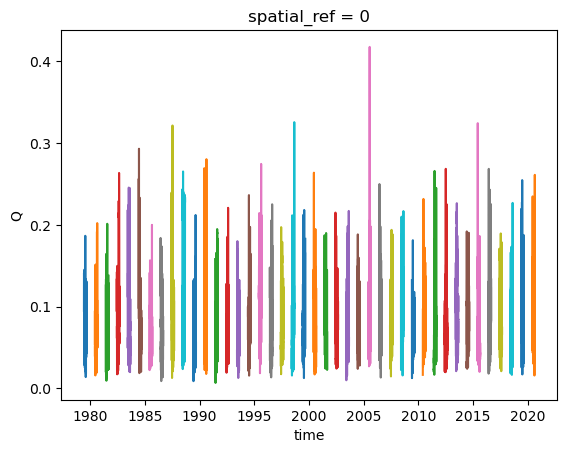

In [4]:
for year in range(1979, 2021):
    wind_winter.sel(time=f"{year}").Q.plot()

In [5]:
# get thresholds using 10th percentile for each state

threshold_percentile = 0.1
thresholds = {}

# for wind threshold, use all data,
# for solar only use winter data
for state in wind.data_vars:
    thresholds[f"solar_{state}"] = solar_winter[state].quantile(threshold_percentile).item()
    thresholds[f"wind_{state}"] = wind[state].quantile(threshold_percentile).item()

In [6]:
thresholds

{'solar_Q': 0.12859422266483309,
 'wind_Q': 0.030083213932812214,
 'solar_N': 0.09107748940587043,
 'wind_N': 0.034490831196308136,
 'solar_V': 0.06676724776625634,
 'wind_V': 0.04026288539171219,
 'solar_S': 0.08736495971679688,
 'wind_S': 0.044248128309845924,
 'solar_T': 0.052090673521161084,
 'wind_T': 0.031058729626238346}

In [7]:
results = {}

for state in ["Q", "N", "V", "S"]:
    solar_threshold = thresholds[f"solar_{state}"]
    wind_threshold = thresholds[f"wind_{state}"]

    for year in range(1979, 2024):
        
        solar_data = solar_winter[state].sel(time=f"{year}")
        wind_data = wind_winter[state].sel(time=f"{year}")
    
        solar_lulls = mbt(
            data=solar_data,
            threshold=solar_threshold,
            length_max=90,
            length_min=3
        )
        wind_lulls = mbt(
            data=wind_data,
            threshold=wind_threshold,
            length_max=90,
            length_min=3
        )

        # get max length of lulls
        valid_solar = solar_lulls.any("time").where(lambda x: x, drop=True)
        max_solar = 0 if valid_solar.sizes["length"] == 0 else valid_solar.length.max().item()
        
        valid_wind = wind_lulls.any("time").where(lambda x: x, drop=True)
        max_wind = 0 if valid_wind.sizes["length"] == 0 else valid_wind.length.max().item()

        # number of lull days
        total_solar = solar_lulls.any("length").sum('time').item()
        total_wind = wind_lulls.any("length").sum('time').item()

        # compound events
        compound_lulls = (solar_lulls.any("length") & wind_lulls.any("length")).sum().item()
        
        if year == 1979:
            results[f'longest_solar_{state}'] = [max_solar]
            results[f'longest_wind_{state}'] = [max_wind]

            results[f"total_solar_{state}"] = [total_solar]
            results[f"total_wind_{state}"] = [total_wind]

            results[f"total_compound_{state}"] = [compound_lulls]
            
            
        else:
            results[f'longest_solar_{state}'].append(max_solar)
            results[f'longest_wind_{state}'].append(max_wind)

            results[f"total_solar_{state}"].append(total_solar)
            results[f"total_wind_{state}"].append(total_wind)

            results[f"total_compound_{state}"].append(compound_lulls)

    print(state)

Q
N
V
S


In [8]:
df = pd.DataFrame(results, index=range(1979, 2024))

In [9]:
region_colors = {
    "Q": "tab:blue",
    "N": "tab:orange",
    "V": "tab:green",
    "S": "tab:red",
}
def get_region(col):
    return col.split("_")[-1]

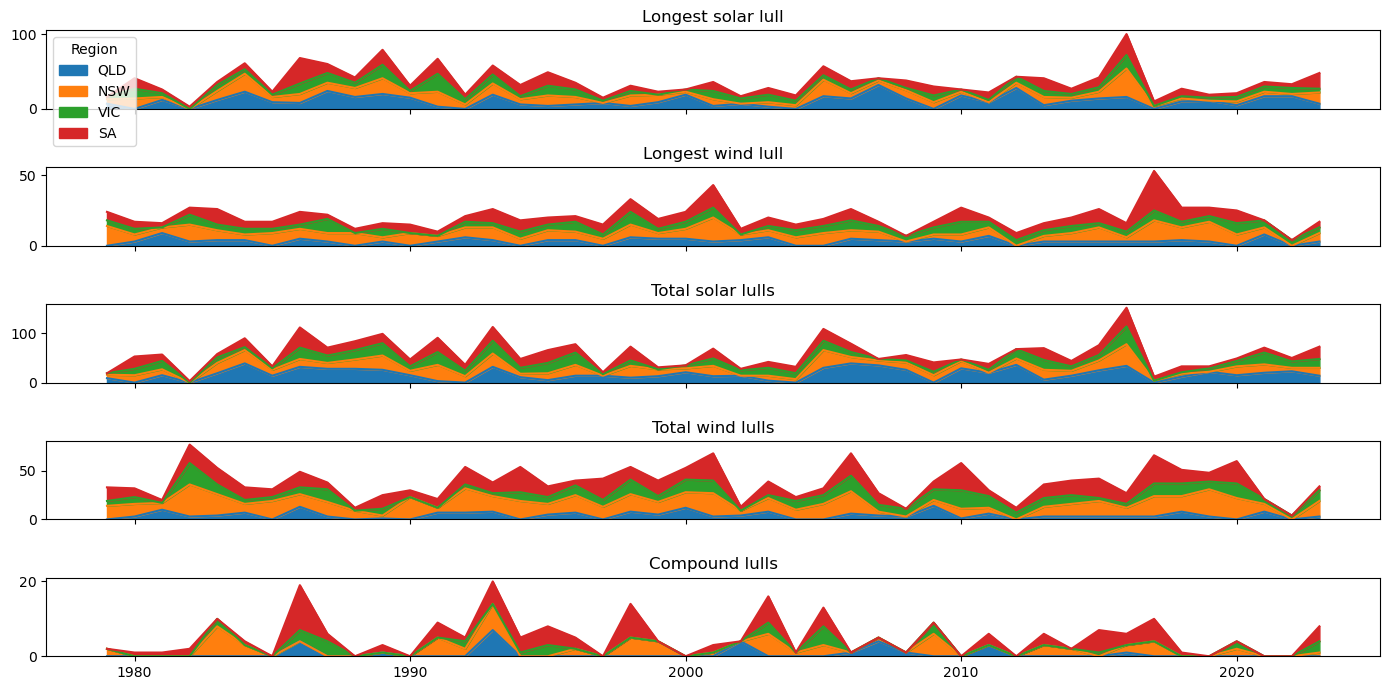

In [25]:
regions = ["Q", "N", "V", "S"]

colors = {
    "Q": "tab:blue",
    "N": "tab:orange",
    "V": "tab:green",
    "S": "tab:red",
}

metrics = [
    ("longest_solar", "Longest solar lull"),
    ("longest_wind", "Longest wind lull"),
    ("total_solar", "Total solar lulls"),
    ("total_wind", "Total wind lulls"),
    ("total_compound", "Compound lulls"),
]

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=1,
    figsize=(14, 7),
    sharex=True,
)

legend = True
for ax, (metric, title) in zip(axes, metrics):
    cols = [f"{metric}_{r}" for r in regions]

    df[cols].plot.area(
        ax=ax,
        color=[colors[r] for r in regions],
        legend=legend
    )

    ax.set_title(title)

    # only include legend in first plot
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["QLD", "NSW", "VIC", "SA"]
        ax.legend(title="Region", loc="upper left", handles=handles, labels=new_labels)

        legend = False

fig.tight_layout()

In [34]:
metrics = [
    ("longest_solar", "Longest solar lull"),
    ("longest_wind", "Longest wind lull"),
    ("total_solar", "Total solar lulls"),
    ("total_wind", "Total wind lulls"),
    ("total_compound", "Compound lulls"),
]

for metric, labels in metrics:
    print(labels)

Longest solar lull
Longest wind lull
Total solar lulls
Total wind lulls
Compound lulls


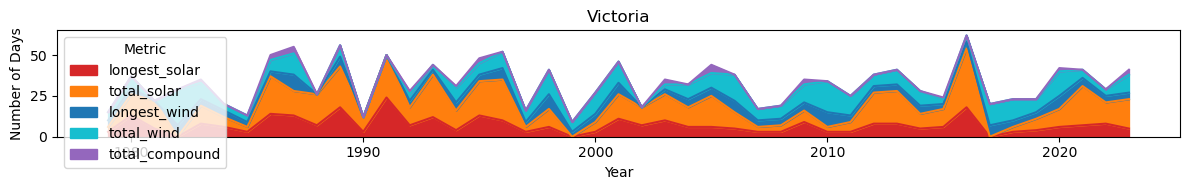

In [136]:
regions = ["Q", "N", "V", "S"]

metrics = [
    "longest_solar_V",
    "total_solar_V",
    "longest_wind_V",
    "total_wind_V", 
    "total_compound_V"
]

labels = [
    "longest_solar",
    "total_solar",
    "longest_wind",
    "total_wind", 
    "total_compound"
]

colors = {
    "longest_solar_V": "tab:red",
    "total_solar_V": "tab:orange",
    "longest_wind_V": "tab:blue",
    "total_wind_V": "tab:cyan",
    "total_compound_V": "tab:purple",
}



fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12, 2),
    sharex=True,
)

df_vic = df[metrics]

df_vic.plot.area(
    ax=ax,
    color=[colors[m] for m in metrics],
)

ax.set_title("Victoria")

    
handles, _ = ax.get_legend_handles_labels()
ax.legend(title="Metric", loc="upper left", handles=handles, labels=labels)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Days")

fig.tight_layout()

In [ ]:
year=1987

In [104]:
wind_lulls = mbt(
    data=wind_winter.V.sel(time="1987"),
    threshold=thresholds['wind_V'],
    length_max=90,
    length_min=3
)

In [116]:
solar_lulls = mbt(
    data=solar_winter.V.sel(time="1987"),
    threshold=thresholds['solar_V'],
    length_max=90,
    length_min=3
)

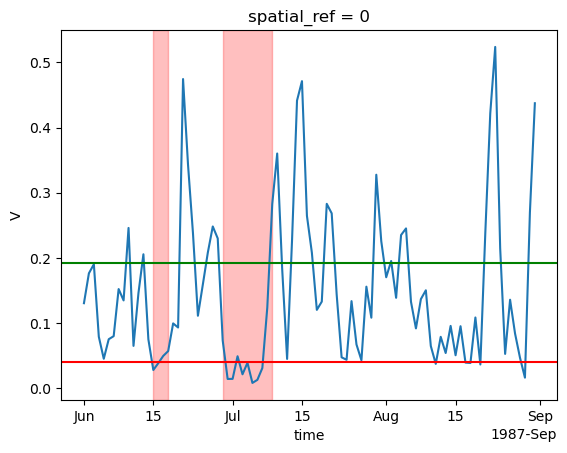

In [105]:
fig, ax = plt.subplots()

wind_winter.V.sel(time="1987").plot()

lull_mask = wind_lulls.any("length")
# lull_mask = lull_mask.fillna(False)

t = lull_mask.time.values
m = lull_mask.values

in_lull = False
start = None

for ti, mi in zip(t, m):

    if mi and not in_lull:
        start = ti
        in_lull = True

    elif not mi and in_lull:
        ax.axvspan(start, ti, color="red", alpha=0.25)
        in_lull = False

# close last span
if in_lull:
    ax.axvspan(start, t[-1], color="red", alpha=0.25)

mean_wind = wind_winter.V.mean().item()
ax.axhline(mean_wind, color='green')
ax.axhline(thresholds['wind_V'], color='red')

In [129]:
wind_winter = wind_winter.drop_vars("spatial_ref")
solar_winter = solar_winter.drop_vars("spatial_ref")

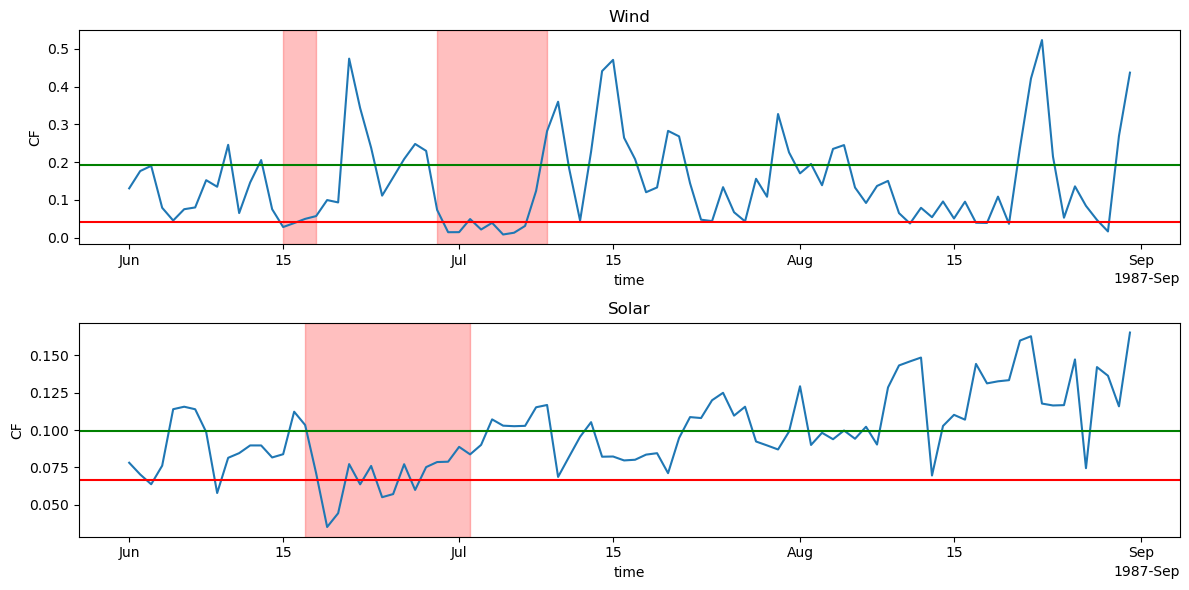

In [134]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))

################################################################################################################
# wind
################################################################################################################

wind_winter.V.sel(time="1987").plot(ax=axes[0])

lull_mask = wind_lulls.any("length")
# lull_mask = lull_mask.fillna(False)

t = lull_mask.time.values
m = lull_mask.values

in_lull = False
start = None

for ti, mi in zip(t, m):

    if mi and not in_lull:
        start = ti
        in_lull = True

    elif not mi and in_lull:
        axes[0].axvspan(start, ti, color="red", alpha=0.25)
        in_lull = False

# close last span
if in_lull:
    axes[0].axvspan(start, t[-1], color="red", alpha=0.25)

mean_wind = wind_winter.V.mean().item()
axes[0].axhline(mean_wind, color='green')
axes[0].axhline(thresholds['wind_V'], color='red')
axes[0].set_title("Wind")

################################################################################################################
# Solar
################################################################################################################

solar_winter.V.sel(time="1987").plot(ax=axes[1])

lull_mask = solar_lulls.any("length")
# lull_mask = lull_mask.fillna(False)

t = lull_mask.time.values
m = lull_mask.values

in_lull = False
start = None

for ti, mi in zip(t, m):

    if mi and not in_lull:
        start = ti
        in_lull = True

    elif not mi and in_lull:
        axes[1].axvspan(start, ti, color="red", alpha=0.25)
        in_lull = False

# close last span
if in_lull:
    axes[1].axvspan(start, t[-1], color="red", alpha=0.25)

mean_solar = solar_winter.V.mean().item()
axes[1].axhline(mean_solar, color='green')
axes[1].axhline(thresholds['solar_V'], color='red')
axes[1].set_title("Solar")

for i in range(2):
    axes[i].set_ylabel("CF")

fig.tight_layout()

In [ ]:
wind.V.sel(time=slice()

In [109]:
wind_lulls.sel(time=slice("1987-06-15", "1987-06-18")).sum("length")

<xarray.DataArray 'V' (time: 4)> Size: 32B
array([1, 1, 1, 0])
Coordinates:
  * time         (time) datetime64[ns] 32B 1987-06-15 1987-06-16 ... 1987-06-18
    spatial_ref  int64 8B 0

In [137]:
solar_lulls.sel(time=slice("1987-06-16", "1987-07-05")).sum("length")

<xarray.DataArray 'V' (time: 20)> Size: 160B
array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0])
Coordinates:
  * time         (time) datetime64[ns] 160B 1987-06-16 1987-06-17 ... 1987-07-05
    spatial_ref  int64 8B 0